In [11]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# -----------------------------
# 1. LOAD + CLEAN DATA
# -----------------------------
df = pd.read_csv("epa_packaging_ml_ready_totals.csv")

df = df.dropna(subset=["generated_tons"])
df = df[df["generated_tons"] > 0].copy()

for col in ["recycled_tons", "landfilled_tons", "combusted_tons"]:
    df[col] = df[col].fillna(0)

df["recycling_rate"] = df["recycled_tons"] / df["generated_tons"]
df["landfill_share"] = df["landfilled_tons"] / df["generated_tons"]
df["combustion_share"] = df["combusted_tons"] / df["generated_tons"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=["recycling_rate", "landfill_share", "combustion_share"]).copy()

# -----------------------------
# 2. CREATE SCORE + CLASS
# -----------------------------
df["sustainability_score"] = (
    100 * df["recycling_rate"]
    - 60 * df["landfill_share"]
    - 20 * df["combustion_share"]
).clip(0, 100)

score = df["sustainability_score"]
cls = np.where(score == 0, "Harmful", None)

pos_mask = score > 0
pos_bins = pd.qcut(score[pos_mask], q=2, labels=["Moderate", "Sustainable"])
cls[pos_mask] = pos_bins.astype(str)

df["sustainability_class"] = cls

# -----------------------------
# 3. FEATURES
# -----------------------------
X_cols = [
    "generated_tons",
    "recycled_tons",
    "landfilled_tons",
    "combusted_tons",
    "recycling_rate",
    "landfill_share",
    "combustion_share"
]

X = df[X_cols]
y_class = df["sustainability_class"]
y_score = df["sustainability_score"]

print("\nClass distribution:")
print(y_class.value_counts())




Class distribution:
sustainability_class
Harmful        109
Sustainable     27
Moderate        27
Name: count, dtype: int64


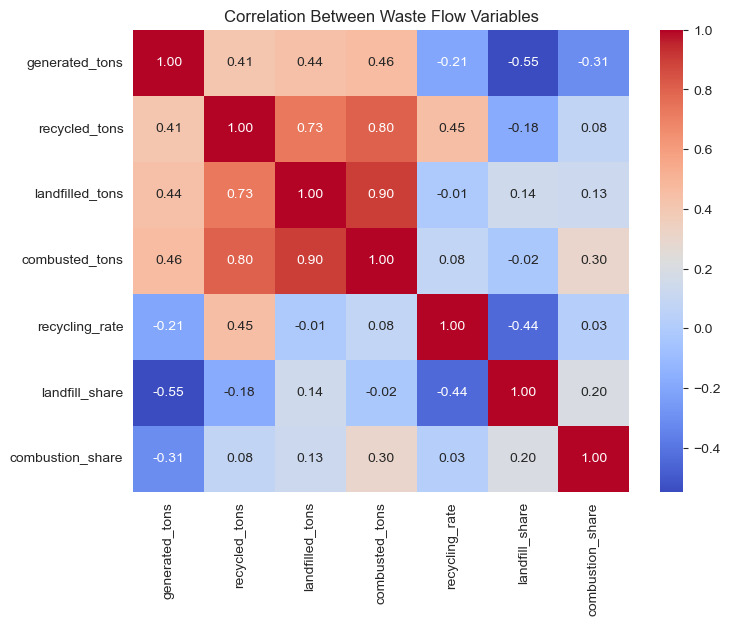

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[X_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Waste Flow Variables")
plt.show()

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

/var/folders/9m/jhq6kvdx0kd7k4d5rdwl3zf00000gn/T/ipykernel_19609/3609617238.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sustainability_class", palette="Set2")


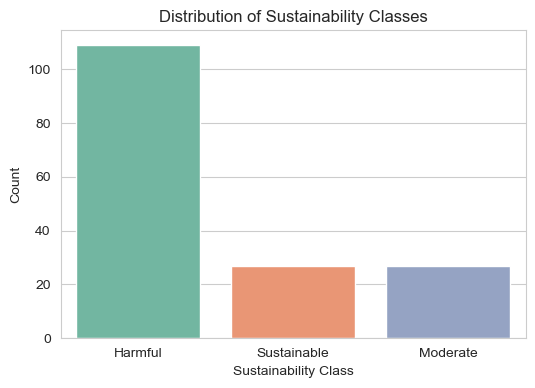

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sustainability_class", palette="Set2")
plt.title("Distribution of Sustainability Classes")
plt.xlabel("Sustainability Class")
plt.ylabel("Count")
plt.show()

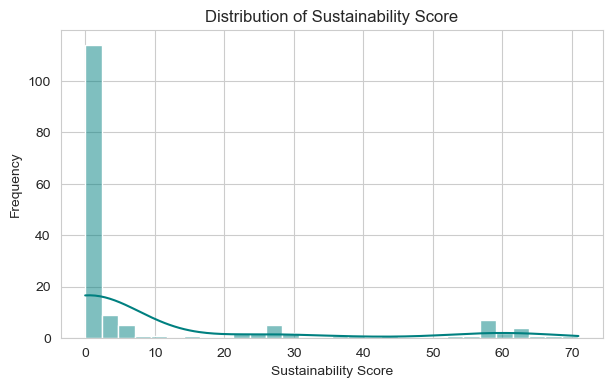

In [26]:
plt.figure(figsize=(7, 4))
sns.histplot(df["sustainability_score"], bins=30, kde=True, color="teal")
plt.title("Distribution of Sustainability Score")
plt.xlabel("Sustainability Score")
plt.ylabel("Frequency")
plt.show()

In [21]:
# -----------------------------
# 4. TRAIN / TEST SPLIT
# -----------------------------
X_train, X_test, y_train_class, y_test_class, y_train_score, y_test_score = train_test_split(
    X, y_class, y_score,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)


In [22]:
# -----------------------------
# 5. MODELS
# -----------------------------
model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        multi_class="multinomial"
    ))
])

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

# -----------------------------
# 6. SMALL RANDOM FOREST TUNING
# -----------------------------
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", None]
}

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train_class)
best_rf = rf_grid.best_estimator_

print("\nBest Random Forest params:")
print(rf_grid.best_params_)



Best Random Forest params:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}


In [23]:
# -----------------------------
# 7. CROSS-VALIDATION COMPARISON
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

cv_lr = cross_validate(model_lr, X, y_class, cv=cv, scoring=scoring)
cv_rf = cross_validate(best_rf, X, y_class, cv=cv, scoring=scoring)

cv_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "CV Accuracy": cv_lr["test_accuracy"].mean(),
        "CV Precision": cv_lr["test_precision_macro"].mean(),
        "CV Recall": cv_lr["test_recall_macro"].mean(),
        "CV Macro F1": cv_lr["test_f1_macro"].mean()
    },
    {
        "Model": "Random Forest",
        "CV Accuracy": cv_rf["test_accuracy"].mean(),
        "CV Precision": cv_rf["test_precision_macro"].mean(),
        "CV Recall": cv_rf["test_recall_macro"].mean(),
        "CV Macro F1": cv_rf["test_f1_macro"].mean()
    }
])

print("\nCross-validation results:")
print(cv_results)


Cross-validation results:
                 Model  CV Accuracy  CV Precision  CV Recall  CV Macro F1
0  Logistic Regression     0.913826      0.880014   0.926234     0.892458
1        Random Forest     0.987689      0.980952   0.973333     0.974929


In [15]:
# -----------------------------
# 8. FINAL FIT ON TRAIN SET
# -----------------------------
model_lr.fit(X_train, y_train_class)
best_rf.fit(X_train, y_train_class)

pred_lr = model_lr.predict(X_test)
pred_rf = best_rf.predict(X_test)

results_test = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test_class, pred_lr),
        "Precision": precision_score(y_test_class, pred_lr, average="macro", zero_division=0),
        "Recall": recall_score(y_test_class, pred_lr, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test_class, pred_lr, average="macro", zero_division=0)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test_class, pred_rf),
        "Precision": precision_score(y_test_class, pred_rf, average="macro", zero_division=0),
        "Recall": recall_score(y_test_class, pred_rf, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test_class, pred_rf, average="macro", zero_division=0)
    }
])

print("\nTest-set results:")
print(results_test)

print("\nLogistic Regression classification report:")
print(classification_report(y_test_class, pred_lr, zero_division=0))

print("\nRandom Forest classification report:")
print(classification_report(y_test_class, pred_rf, zero_division=0))


Test-set results:
                 Model  Accuracy  Precision    Recall  Macro F1
0  Logistic Regression  0.878788   0.866667  0.887879  0.855239
1        Random Forest  0.969697   0.952381  0.933333  0.937322

Logistic Regression classification report:
              precision    recall  f1-score   support

     Harmful       1.00      0.86      0.93        22
    Moderate       0.60      1.00      0.75         6
 Sustainable       1.00      0.80      0.89         5

    accuracy                           0.88        33
   macro avg       0.87      0.89      0.86        33
weighted avg       0.93      0.88      0.89        33


Random Forest classification report:
              precision    recall  f1-score   support

     Harmful       1.00      1.00      1.00        22
    Moderate       0.86      1.00      0.92         6
 Sustainable       1.00      0.80      0.89         5

    accuracy                           0.97        33
   macro avg       0.95      0.93      0.94        33


In [16]:
# -----------------------------
# 9. SCORE REGRESSION MODEL
# -----------------------------
score_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    min_samples_leaf=2
)

score_model.fit(X_train, y_train_score)
pred_score = score_model.predict(X_test)

print("\nScore regression performance:")
print("MAE:", mean_absolute_error(y_test_score, pred_score))
print("RMSE:", np.sqrt(mean_squared_error(y_test_score, pred_score)))
print("R2:", r2_score(y_test_score, pred_score))


Score regression performance:
MAE: 0.40157437981658456
RMSE: 0.8050800431751299
R2: 0.996853037607981


In [17]:
# -----------------------------
# 10. SAVE MODELS FOR STREAMLIT
# -----------------------------
joblib.dump(model_lr, "logistic_model.pkl")
joblib.dump(best_rf, "random_forest_model.pkl")
joblib.dump(X_cols, "feature_columns.pkl")
joblib.dump(results_test, "test_results.pkl")
joblib.dump(df, "cleaned_df.pkl")

print("\nModels and data saved for Streamlit app.")


Models and data saved for Streamlit app.


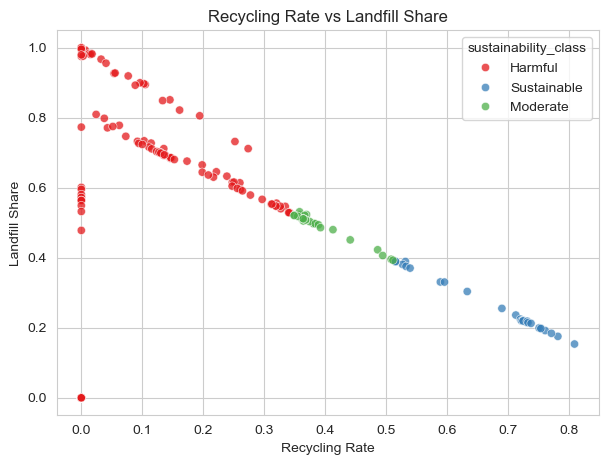

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="recycling_rate",
    y="landfill_share",
    hue="sustainability_class",
    palette="Set1",
    alpha=0.75
)
plt.title("Recycling Rate vs Landfill Share")
plt.xlabel("Recycling Rate")
plt.ylabel("Landfill Share")
plt.show()

In [28]:
best_model = results_test.loc[results_test["Macro F1"].idxmax(), "Model"]
best_f1 = results_test["Macro F1"].max()

print(f"Final selected classification model: {best_model}")
print(f"Reason: highest Macro F1 on the test set = {best_f1:.3f}")

Final selected classification model: Random Forest
Reason: highest Macro F1 on the test set = 0.937


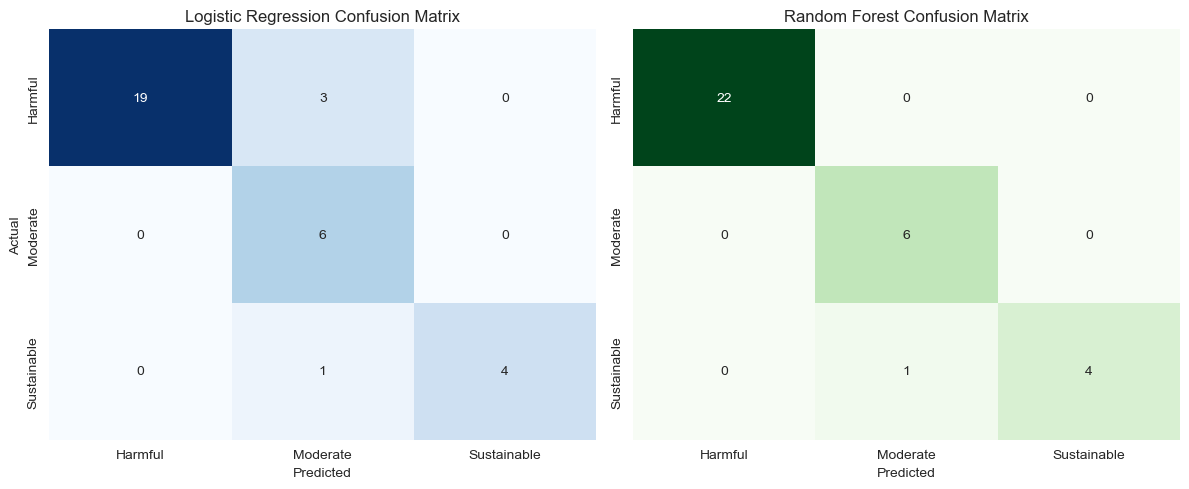

In [29]:
from sklearn.metrics import confusion_matrix

labels = sorted(y_class.unique())

cm_lr = confusion_matrix(y_test_class, pred_lr, labels=labels)
cm_rf = confusion_matrix(y_test_class, pred_rf, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False)
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1], cbar=False)
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

/var/folders/9m/jhq6kvdx0kd7k4d5rdwl3zf00000gn/T/ipykernel_19609/1763607014.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance, x="Importance", y="Feature", palette="viridis")


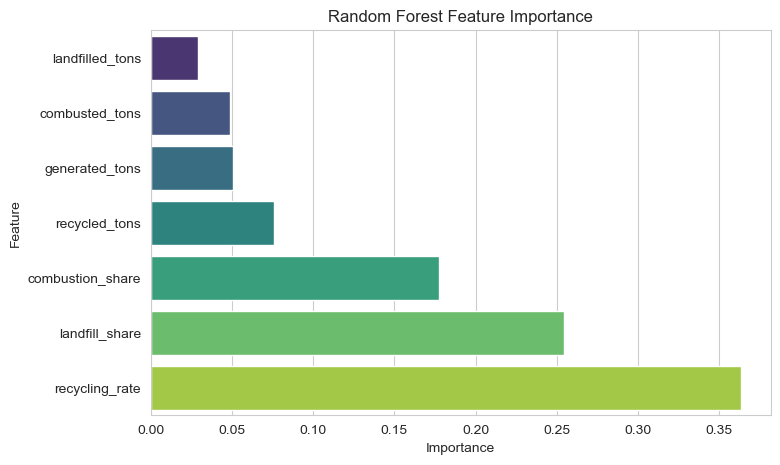

In [30]:
rf_importance = pd.DataFrame({
    "Feature": X_cols,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance")
plt.show()